# 04_StrategyA — Val 정상 trial을 Train에 포함

**변경 사항**: Val5(217A), Val8(237A), Val9(237A) 정상 trial → Train 편입

| Split | 이전 | 변경 후 |
|---|---|---|
| Train | Test1-43 (정상6, 이상6) | + Val5,8,9 추가 (정상9, 이상6) |
| Val (EarlyStop) | Test44, Test45 | 동일 |
| **Test** | **Val1,2,5,8,9** (정상3, 이상2) | **Val1, Val2만** (이상 2개) |

> ⚠️ Test에 정상 trial이 없으므로 AUC 계산 불가. 이상 검출 recall로 평가.

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost', 'scipy'])

0

In [2]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'strategyA_model'
MODEL_DIR.mkdir(exist_ok=True)

WINDOW_SIZE = 30
STEP_SIZE   = 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1,2,3,4,5,7,8,9,10,11,12,28,29,30,44}
ABNORMAL_TEST_IDS = {6,31,45} | set(range(32,44))
NORMAL_VAL_IDS    = set(range(3,10))
ABNORMAL_VAL_IDS  = {1,2}
VAL_TRIAL_IDS     = {44,45}          # EarlyStopping val
VAL_TO_TRAIN_IDS  = {5,8,9}          # ★ 정상 Val → Train 편입

RNN_HIDDEN_1=64; RNN_HIDDEN_2=32; DROPOUT_RATE=0.3
EPOCHS=200; BATCH_SIZE=32; LEARNING_RATE=1e-3; PATIENCE=20
SEED=42

print('WINDOW_SIZE:', WINDOW_SIZE, '/ STEP_SIZE:', STEP_SIZE)

WINDOW_SIZE: 30 / STEP_SIZE: 10


In [3]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from scipy.stats import linregress
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, recall_score
import xgboost as xgb

import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Device: cuda


In [4]:
# ── 데이터 로드 (Val5,8,9 → train) ──────────────────────────────

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    return (m.group(1).capitalize(), int(m.group(2))) if m else (None, None)

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':
        if idx in VAL_TO_TRAIN_IDS: return 'train'   # ★ 변경
        return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

def engineer(data_norm):
    V = data_norm[:,0:1]; I = data_norm[:,1:2]
    return np.hstack([V, I,
                      np.diff(V,axis=0,prepend=V[[0]]),
                      np.diff(I,axis=0,prepend=I[[0]]),
                      V*I])

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    try: label=get_label(prefix,idx); split=get_split(prefix,idx)
    except: continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue
    data = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    m,s  = data.mean(0), data.std(0); s[s<1e-8]=1e-8
    records.append({'folder':d.name,'label':label,'split':split,
                    'data':engineer((data-m)/s)})

def make_windows(data,ws,ss):
    return np.stack([data[s:s+ws] for s in range(0,len(data)-ws+1,ss)])

buckets = {'train':([],[]),'val':([],[]),'test':([],[])}
test_folders = []
for r in records:
    w = make_windows(r['data'],WINDOW_SIZE,STEP_SIZE)
    lb= np.full(len(w),r['label'],dtype=np.float32)
    buckets[r['split']][0].append(w)
    buckets[r['split']][1].append(lb)
    if r['split']=='test': test_folders.extend([r['folder']]*len(w))

X = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y = {s: np.concatenate(buckets[s][1])               for s in buckets}
test_folders = np.array(test_folders)

# 글로벌 스케일러
n_feat = X['train'].shape[2]
scaler = StandardScaler()
scaler.fit(X['train'].reshape(-1,n_feat))
def scale(a):
    n,w,f=a.shape
    return scaler.transform(a.reshape(-1,f)).reshape(n,w,f).astype(np.float32)
Xs = {s: scale(X[s]) for s in X}

for s in ('train','val','test'):
    u,c=np.unique(y[s],return_counts=True); cnt=dict(zip(u.astype(int),c))
    print(f'{s:5s}  total={len(y[s]):4d}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')
print('\n[Test trials]')
for f in sorted(set(test_folders)): print(' ', f)

train  total= 459  normal= 278  abnormal= 181
val    total=  58  normal=  29  abnormal=  29
test   total=  55  normal=   0  abnormal=  55

[Test trials]
  Val1_130A_22TS_170WFR
  Val2_130A_24TS_200WFR


In [5]:
# ── 윈도우 통계 피처 (RF / XGBoost) ──────────────────────────────
FEAT_NAMES = ['V','I','dV','dI','VI']
STAT_NAMES = ['mean','std','min','max','range','slope']

def window_stats(windows):
    N=len(windows); t=np.arange(WINDOW_SIZE)
    out=np.zeros((N,len(FEAT_NAMES)*len(STAT_NAMES)),dtype=np.float32)
    for i,w in enumerate(windows):
        row=[]
        for f in range(len(FEAT_NAMES)):
            c=w[:,f]; sl=linregress(t,c).slope
            row.extend([c.mean(),c.std(),c.min(),c.max(),c.max()-c.min(),sl])
        out[i]=row
    return out

Xf = {s: window_stats(Xs[s]) for s in Xs}
fs  = StandardScaler(); fs.fit(Xf['train'])
Xf  = {s: fs.transform(Xf[s]).astype(np.float32) for s in Xf}
Xf_tv = np.vstack([Xf['train'],Xf['val']])
yf_tv  = np.concatenate([y['train'],y['val']]).astype(int)
col_names = [f'{f}_{s}' for f in FEAT_NAMES for s in STAT_NAMES]
print('통계 피처 shape:', Xf['train'].shape)

통계 피처 shape: (459, 30)


In [6]:
# ── 공통 평가 (test = 이상만이므로 AUC 생략, recall 보고) ─────────

def evaluate_A(model_name, y_true, y_score, folders, threshold=0.5):
    y_pred = (y_score >= threshold).astype(int)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    print(f'\n===== {model_name} (threshold={threshold:.2f}) =====')
    print(classification_report(y_true, y_pred,
                                labels=[0,1],
                                target_names=['Normal(0)','Abnormal(1)'],
                                zero_division=0))
    print(f'Abnormal Recall: {rec:.3f}')
    print(f'\n{"Trial":45s}  {"True":5s}  {"Windows":7s}  {"MeanScore":9s}  판정')
    print('-'*80)
    for folder in sorted(set(folders)):
        mask   = folders==folder
        sc_m   = y_score[mask].mean()
        true_l = int(y_true[mask][0])
        pred_l = 1 if sc_m>=threshold else 0
        ok     = 'O' if pred_l==true_l else 'X'
        print(f'{folder:45s}  {true_l:5d}  {mask.sum():7d}  {sc_m:9.3f}  {ok}')
    return rec

RF 최적 threshold (val 기준): 0.45  val_F1=1.000

===== Random Forest (threshold=0.45) =====
              precision    recall  f1-score   support

   Normal(0)       0.00      0.00      0.00         0
 Abnormal(1)       1.00      0.07      0.14        55

    accuracy                           0.07        55
   macro avg       0.50      0.04      0.07        55
weighted avg       1.00      0.07      0.14        55

Abnormal Recall: 0.073

Trial                                          True   Windows  MeanScore  판정
--------------------------------------------------------------------------------
Val1_130A_22TS_170WFR                              1       24      0.284  X
Val2_130A_24TS_200WFR                              1       31      0.195  X


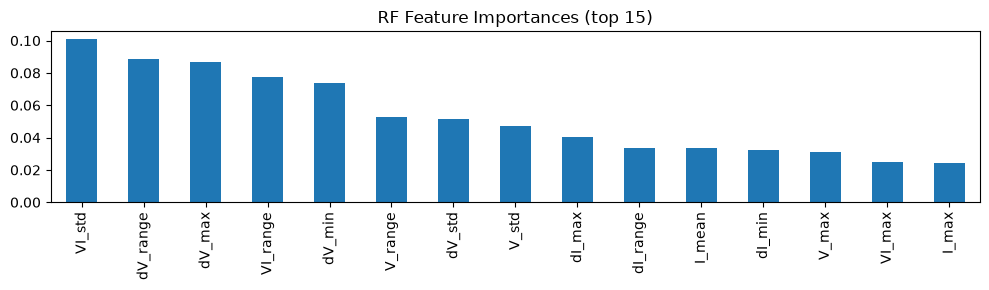

In [7]:
# ── Random Forest ─────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=2,
                             class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(Xf_tv, yf_tv)
rf_prob = rf.predict_proba(Xf['test'])[:,1]

# val 세트로 최적 threshold 탐색
rf_val_prob = rf.predict_proba(Xf['val'])[:,1]
from sklearn.metrics import f1_score
best_t, best_f1 = 0.5, 0
for t in np.arange(0.1, 0.9, 0.05):
    p = (rf_val_prob>=t).astype(int)
    f = f1_score(y['val'].astype(int), p, zero_division=0)
    if f > best_f1: best_f1=f; best_t=t
print(f'RF 최적 threshold (val 기준): {best_t:.2f}  val_F1={best_f1:.3f}')

rec_rf = evaluate_A('Random Forest', y['test'].astype(int), rf_prob, test_folders, threshold=best_t)

# 피처 중요도
imp = pd.Series(rf.feature_importances_, index=col_names).sort_values(ascending=False)
imp[:15].plot(kind='bar', figsize=(10,3), title='RF Feature Importances (top 15)')
plt.tight_layout(); plt.savefig(str(MODEL_DIR/'rf_imp.png'),dpi=150); plt.show()

In [8]:
# ── XGBoost ───────────────────────────────────────────────────────
sp = int((yf_tv==0).sum())/int((yf_tv==1).sum())
xg = xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8,
                        scale_pos_weight=sp, eval_metric='logloss',
                        random_state=SEED, verbosity=0)
xg.fit(Xf['train'], y['train'].astype(int),
       eval_set=[(Xf['val'], y['val'].astype(int))], verbose=False)

xg_prob     = xg.predict_proba(Xf['test'])[:,1]
xg_val_prob = xg.predict_proba(Xf['val'])[:,1]

best_t_xg, best_f1_xg = 0.5, 0
for t in np.arange(0.1, 0.9, 0.05):
    p = (xg_val_prob>=t).astype(int)
    f = f1_score(y['val'].astype(int), p, zero_division=0)
    if f > best_f1_xg: best_f1_xg=f; best_t_xg=t
print(f'XGB 최적 threshold (val 기준): {best_t_xg:.2f}  val_F1={best_f1_xg:.3f}')

rec_xg = evaluate_A('XGBoost', y['test'].astype(int), xg_prob, test_folders, threshold=best_t_xg)

XGB 최적 threshold (val 기준): 0.45  val_F1=0.742

===== XGBoost (threshold=0.45) =====
              precision    recall  f1-score   support

   Normal(0)       0.00      0.00      0.00         0
 Abnormal(1)       1.00      0.05      0.10        55

    accuracy                           0.05        55
   macro avg       0.50      0.03      0.05        55
weighted avg       1.00      0.05      0.10        55

Abnormal Recall: 0.055

Trial                                          True   Windows  MeanScore  판정
--------------------------------------------------------------------------------
Val1_130A_22TS_170WFR                              1       24      0.072  X
Val2_130A_24TS_200WFR                              1       31      0.054  X


Ep   1  tr=0.6762/0.5969  vl=0.7305/0.5000
Ep  10  tr=0.3764/0.8780  vl=0.8823/0.5345
Ep  20  tr=0.3182/0.8932  vl=0.8781/0.5345
EarlyStop ep=23
완료 best_val_loss=0.7093


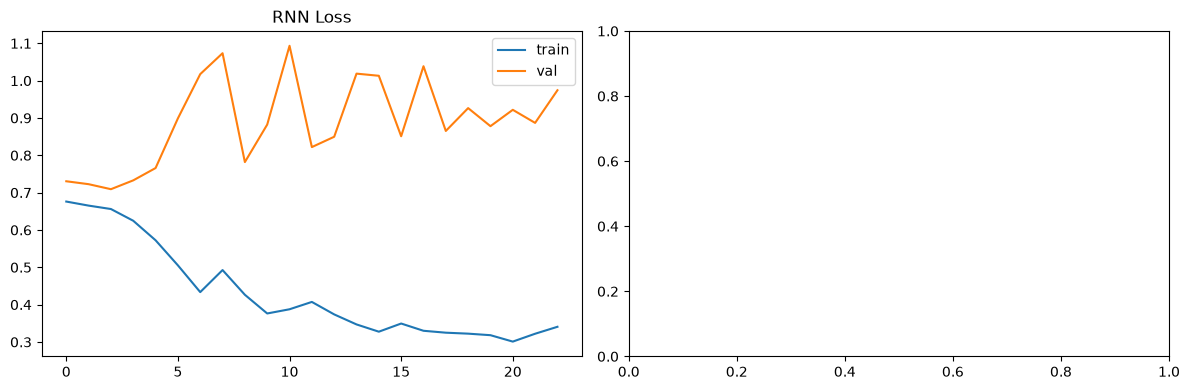

In [9]:
# ── RNN ───────────────────────────────────────────────────────────
class RNNAnomalyDetector(nn.Module):
    def __init__(self, n_features, h1, h2, drop):
        super().__init__()
        self.rnn1=nn.RNN(n_features,h1,batch_first=True,nonlinearity='tanh')
        self.d1  =nn.Dropout(drop)
        self.rnn2=nn.RNN(h1,h2,batch_first=True,nonlinearity='tanh')
        self.d2  =nn.Dropout(drop)
        self.fc  =nn.Linear(h2,1)
    def forward(self,x):
        o,_=self.rnn1(x); o=self.d1(o)
        o,_=self.rnn2(o); o=self.d2(o[:,-1,:])
        return torch.sigmoid(self.fc(o)).squeeze(-1)

class WDS(Dataset):
    def __init__(self,X,y): self.X=torch.from_numpy(X); self.y=torch.from_numpy(y)
    def __len__(self): return len(self.y)
    def __getitem__(self,i): return self.X[i],self.y[i]

rnn   = RNNAnomalyDetector(n_feat,RNN_HIDDEN_1,RNN_HIDDEN_2,DROPOUT_RATE).to(DEVICE)
crit  = nn.BCELoss()
optim = torch.optim.Adam(rnn.parameters(), lr=LEARNING_RATE)
trl   = DataLoader(WDS(Xs['train'],y['train']),BATCH_SIZE,shuffle=True)
vll   = DataLoader(WDS(Xs['val'],  y['val']),  BATCH_SIZE)
tel   = DataLoader(WDS(Xs['test'], y['test']), BATCH_SIZE)

def run_ep(loader, train=False):
    rnn.train() if train else rnn.eval()
    tl,tc,tn=0,0,0
    ctx=torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb,yb in loader:
            Xb,yb=Xb.to(DEVICE),yb.to(DEVICE)
            if train: optim.zero_grad()
            p=rnn(Xb); l=crit(p,yb)
            if train: l.backward(); optim.step()
            tl+=l.item()*len(yb); tc+=((p>=.5).float()==yb).sum().item(); tn+=len(yb)
    return tl/tn, tc/tn

best_vl=float('inf'); pc=0; rnn_path=str(MODEL_DIR/'best_rnn.pt')
hist={'tl':[],'vl':[]}
for ep in range(1,EPOCHS+1):
    tl,ta=run_ep(trl,True); vl,va=run_ep(vll)
    hist['tl'].append(tl); hist['vl'].append(vl)
    if ep%10==0 or ep==1:
        print(f'Ep {ep:3d}  tr={tl:.4f}/{ta:.4f}  vl={vl:.4f}/{va:.4f}')
    if vl<best_vl: best_vl=vl; pc=0; torch.save(rnn.state_dict(),rnn_path)
    else:
        pc+=1
        if pc>=PATIENCE: print(f'EarlyStop ep={ep}'); break
rnn.load_state_dict(torch.load(rnn_path,map_location=DEVICE))
print(f'완료 best_val_loss={best_vl:.4f}')

fig,ax=plt.subplots(1,2,figsize=(12,4))
ax[0].plot(hist['tl'],label='train'); ax[0].plot(hist['vl'],label='val'); ax[0].legend(); ax[0].set_title('RNN Loss')
plt.tight_layout(); plt.savefig(str(MODEL_DIR/'rnn_curve.png'),dpi=150); plt.show()

In [10]:
# RNN 평가
rnn.eval()
rnn_prob_val,rnn_prob_test=[],[]
with torch.no_grad():
    for Xb,_ in vll: rnn_prob_val.append(rnn(Xb.to(DEVICE)).cpu().numpy())
    for Xb,_ in tel: rnn_prob_test.append(rnn(Xb.to(DEVICE)).cpu().numpy())
rnn_prob_val  = np.concatenate(rnn_prob_val)
rnn_prob_test = np.concatenate(rnn_prob_test)

best_t_rnn,best_f1_rnn=0.5,0
for t in np.arange(0.1,0.9,0.05):
    p=(rnn_prob_val>=t).astype(int)
    f=f1_score(y['val'].astype(int),p,zero_division=0)
    if f>best_f1_rnn: best_f1_rnn=f; best_t_rnn=t
print(f'RNN 최적 threshold (val 기준): {best_t_rnn:.2f}  val_F1={best_f1_rnn:.3f}')

rec_rnn=evaluate_A('RNN', y['test'].astype(int), rnn_prob_test, test_folders, threshold=best_t_rnn)

RNN 최적 threshold (val 기준): 0.10  val_F1=0.667

===== RNN (threshold=0.10) =====
              precision    recall  f1-score   support

   Normal(0)       0.00      0.00      0.00         0
 Abnormal(1)       1.00      1.00      1.00        55

    accuracy                           1.00        55
   macro avg       0.50      0.50      0.50        55
weighted avg       1.00      1.00      1.00        55

Abnormal Recall: 1.000

Trial                                          True   Windows  MeanScore  판정
--------------------------------------------------------------------------------
Val1_130A_22TS_170WFR                              1       24      0.385  O
Val2_130A_24TS_200WFR                              1       31      0.391  O


In [11]:
# ── 비교 요약 ──────────────────────────────────────────────────────
summary = pd.DataFrame({
    'Model':          ['Random Forest','XGBoost','RNN'],
    'Threshold':      [best_t, best_t_xg, best_t_rnn],
    'Abnormal Recall':[rec_rf, rec_xg, rec_rnn],
    'Note':           ['val F1 최적화','val F1 최적화','val F1 최적화'],
})
print('=== Strategy A 결과 (Test = Val1, Val2 — 모두 이상) ===')
print(summary.to_string(index=False))
print('\nRecall=1.0 이면 Val1, Val2 모두 이상으로 올바르게 검출된 것')

=== Strategy A 결과 (Test = Val1, Val2 — 모두 이상) ===
        Model  Threshold  Abnormal Recall       Note
Random Forest       0.45         0.072727 val F1 최적화
      XGBoost       0.45         0.054545 val F1 최적화
          RNN       0.10         1.000000 val F1 최적화

Recall=1.0 이면 Val1, Val2 모두 이상으로 올바르게 검출된 것
